# Hodrick Prescott Filter
## Seperating Cycles and Trend

In [2]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../Data/GDP.csv')
df.head()

,DATE,GDP
0,1947-01-01,243.164
1,1947-04-01,245.968
2,1947-07-01,249.585
3,1947-10-01,259.745
4,1948-01-01,265.742


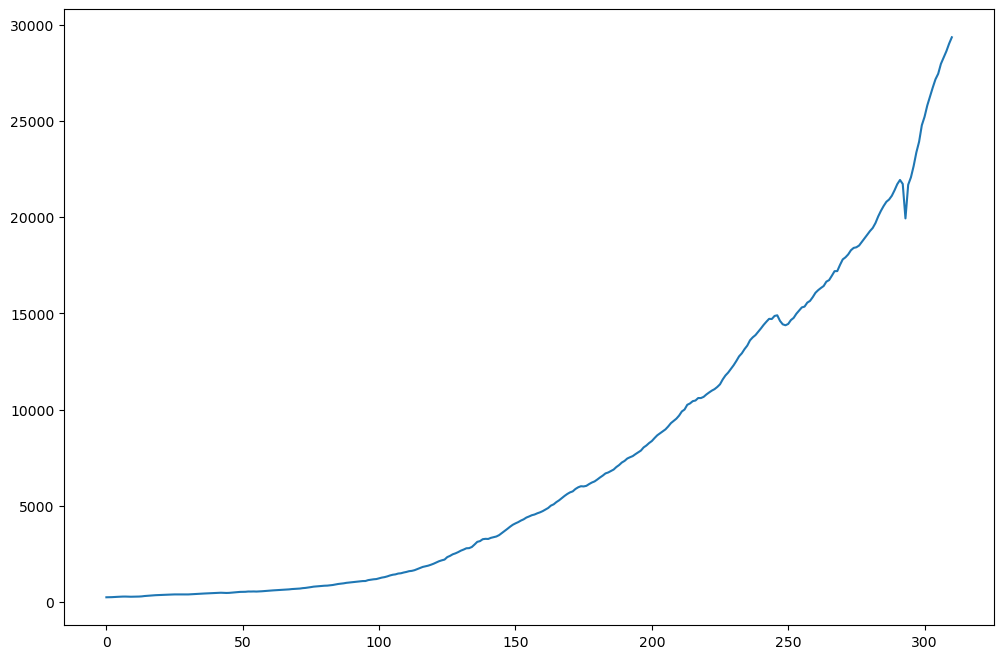

In [6]:
fig = plt.figure(figsize=(12, 8))
plt.plot(df['GDP'])

In [8]:
cycle, trend = sm.tsa.filters.hpfilter(df['GDP'])

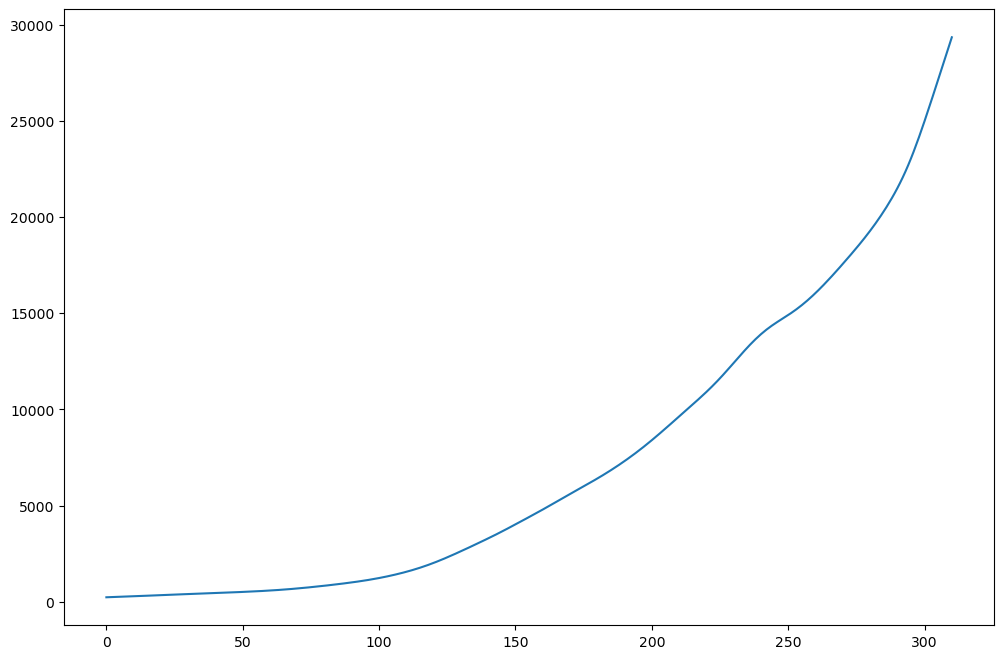

In [10]:
fig = plt.figure(figsize=(12, 8))
plt.plot(trend)

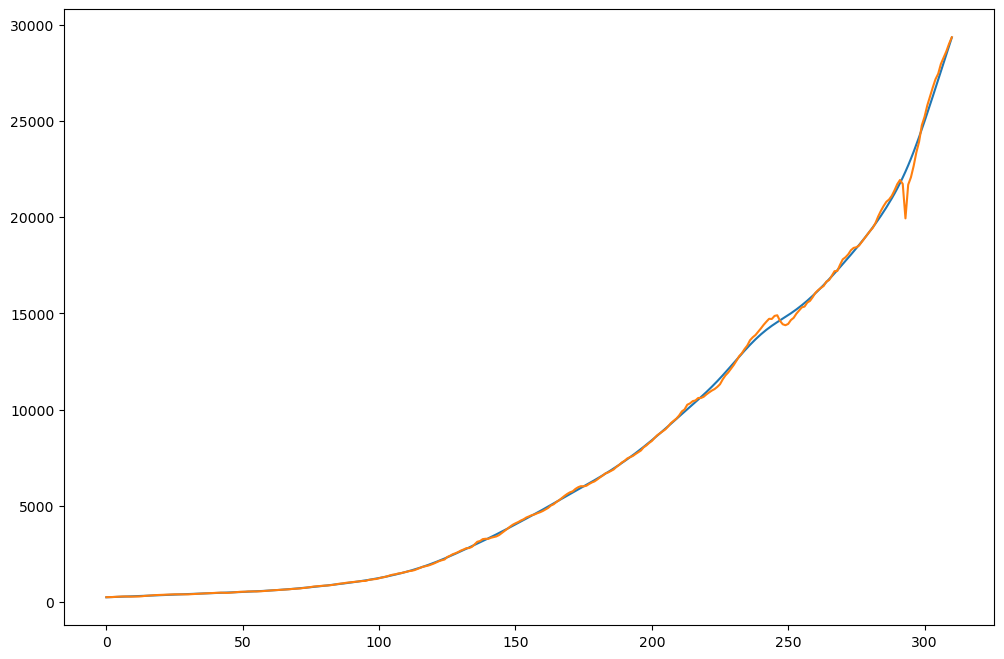

In [12]:
fig = plt.figure(figsize=(12, 8))
plt.plot(trend)
plt.plot(df['GDP'])

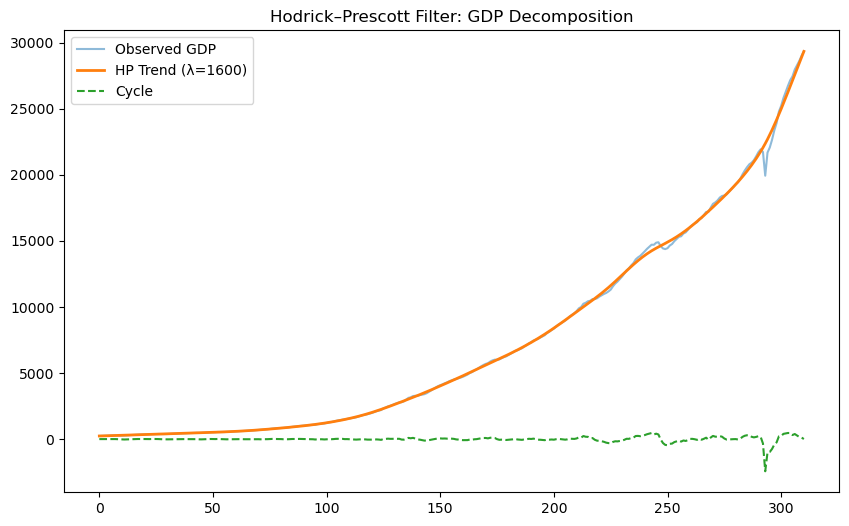

In [14]:
cycle, trend = sm.tsa.filters.hpfilter(df['GDP'], lamb=1600)

plt.figure(figsize=(10,6))
plt.plot(df.index, df['GDP'], label='Observed GDP', alpha=0.5)
plt.plot(df.index, trend, label='HP Trend (λ=1600)', linewidth=2)
plt.plot(df.index, cycle, label='Cycle', linestyle='--')
plt.legend()
plt.title('Hodrick–Prescott Filter: GDP Decomposition')
plt.show()

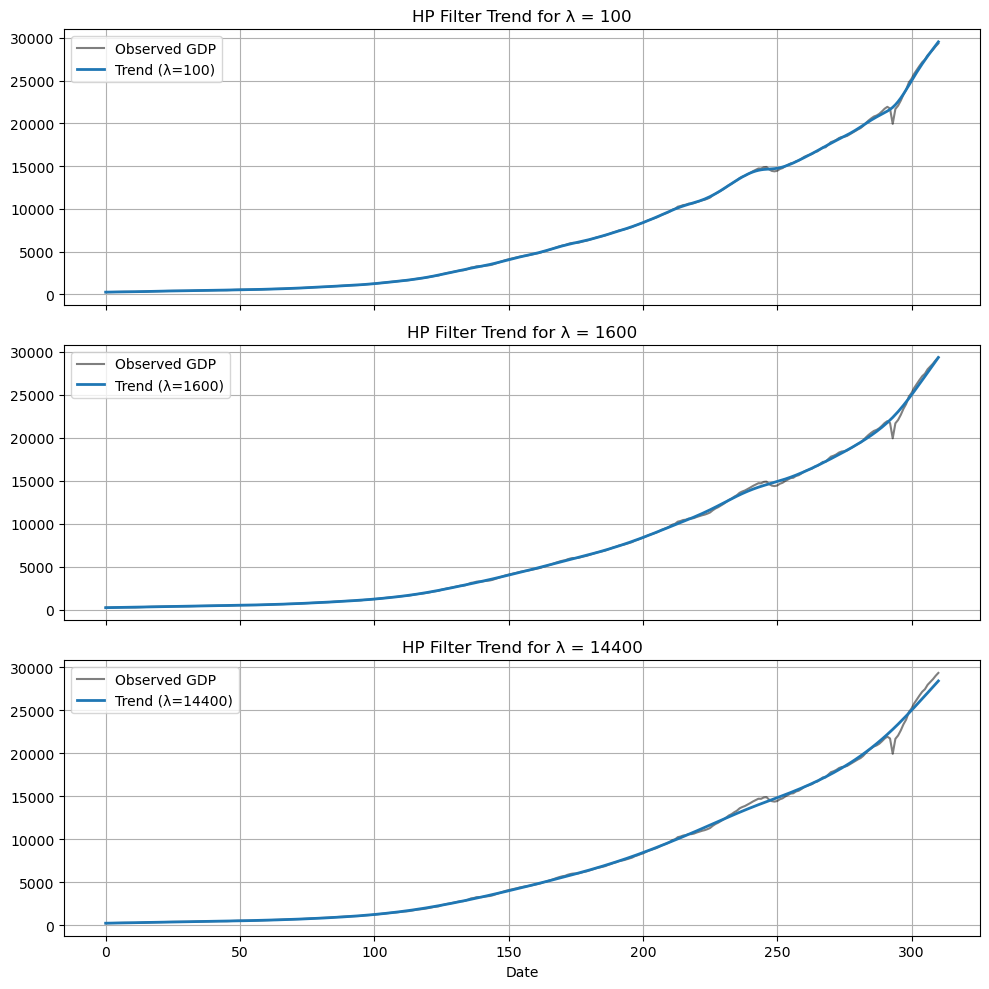

In [18]:
plambdas = [100, 1600, 14400]

y = df['GDP']

fig, axes = plt.subplots(len(lambdas), 1, figsize=(10, 10), sharex=True)

for i, lam in enumerate(lambdas):
    cycle, trend = sm.tsa.filters.hpfilter(y, lamb=lam)
    
    axes[i].plot(y, label='Observed GDP', color='black', alpha=0.5)
    axes[i].plot(trend, label=f'Trend (λ={lam})', linewidth=2, color='tab:blue')
    
    axes[i].set_title(f'HP Filter Trend for λ = {lam}')
    axes[i].legend(loc='upper left')
    axes[i].grid(True)

plt.xlabel('Date')
plt.tight_layout()
plt.show()